<a href="https://colab.research.google.com/github/jmvelasquezg/jmvelasquezg1/blob/sistema/Copia_de_Modelos_de_Difusion_IA_UNJBG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Modelos de difusión

In [1]:
!wget https://github.com/ichaparroc/IA-ESIS-UNJBG/raw/main/GenAI.zip
!unzip GenAI.zip

--2024-07-09 01:38:18--  https://github.com/ichaparroc/IA-ESIS-UNJBG/raw/main/GenAI.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ichaparroc/IA-ESIS-UNJBG/main/GenAI.zip [following]
--2024-07-09 01:38:19--  https://raw.githubusercontent.com/ichaparroc/IA-ESIS-UNJBG/main/GenAI.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24221606 (23M) [application/zip]
Saving to: ‘GenAI.zip’

GenAI.zip           100%[===================>]  23.10M  --.-KB/s    in 0.06s   

2024-07-09 01:38:19 (396 MB/s) - ‘GenAI.zip’ saved [24221606/24221606]

Archive:  GenAI.zip
   creating: images/
  inflating:

En el cuaderno anterior, aprendimos a separar el ruido de una imagen utilizando una U-Net, pero no era capaz de generar nuevas imágenes creíbles a partir del ruido. Los modelos de difusión son mucho mejores generando imágenes a partir de cero.

La buena noticia es que nuestro modelo de red neuronal no cambiará mucho. Nos basaremos en la arquitectura de U-Net con algunas ligeras modificaciones.

En cambio, la gran diferencia es cómo utilizamos nuestro modelo. En lugar de añadir ruido a nuestras imágenes de una sola vez, añadiremos una pequeña cantidad de ruido varias veces. A continuación, podemos utilizar nuestra red neuronal en una imagen ruidosa varias veces para generar una nueva imagen así:

<center><img src="images/rev_diffusion.png" /></center>

#### Objetivos de aprendizaje

Los objetivos de este cuaderno son:
* Construir un programa de varianza de difusión hacia adelante.
* Definir la función de difusión hacia adelante, `q`.
* Actualizar la arquitectura U-Net para acomodar un paso de tiempo, `t`.
* Entrenar un modelo para detectar ruido añadido a una imagen basado en el paso de tiempo `t`.
* Definir una función de difusión inversa para emular `p`.
* Intentar generar prendas de vestir (de nuevo).

Hemos movido algunas de las funciones del cuaderno anterior a un archivo [other_utils.py](utils/other_utils.py). Podemos usarlo para recargar el conjunto de datos fashionMNIST:

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.optim import Adam

# Visualization tools
import matplotlib.pyplot as plt
from IPython.display import Image

# User defined libraries
from utils import other_utils

IMG_SIZE = 16
IMG_CH = 1
BATCH_SIZE = 128
data, dataloader = other_utils.load_transformed_fashionMNIST(IMG_SIZE, BATCH_SIZE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

100%|██████████| 26421880/26421880 [00:07<00:00, 3347631.53it/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 171915.85it/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:01<00:00, 3044406.74it/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 18710811.95it/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



## 2.1 Difusión hacia delante

Sea `T` el número de veces que añadiremos ruido a una imagen. Podemos utilizar `t` para llevar la cuenta del `timestep` actual.

En el cuaderno anterior, utilizamos el término `beta` para representar qué porcentaje de la nueva imagen era ruido en comparación con la imagen original. El valor por defecto era 50% de ruido y 50% de la imagen original. Esta vez, utilizaremos un `programa de variación`, representado como $\beta_t$, o `B` en código. Esto describirá cuánto ruido se añadirá a nuestra imagen en cada paso de tiempo `t`.

En la sección 4 del artículo [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239?ref=assemblyai.com), los autores discuten el arte de definir un buen programa. Debe ser lo suficientemente grande como para que el modelo reconozca que se ha añadido ruido (sobre todo porque la imagen puede ser ya ruidosa), pero lo más pequeño posible.

In [3]:
nrows = 10
ncols = 15

T = nrows * ncols
start = 0.0001
end = 0.02
B = torch.linspace(start, end, T).to(device)
B

tensor([1.0000e-04, 2.3356e-04, 3.6711e-04, 5.0067e-04, 6.3423e-04, 7.6779e-04,
        9.0134e-04, 1.0349e-03, 1.1685e-03, 1.3020e-03, 1.4356e-03, 1.5691e-03,
        1.7027e-03, 1.8362e-03, 1.9698e-03, 2.1034e-03, 2.2369e-03, 2.3705e-03,
        2.5040e-03, 2.6376e-03, 2.7711e-03, 2.9047e-03, 3.0383e-03, 3.1718e-03,
        3.3054e-03, 3.4389e-03, 3.5725e-03, 3.7060e-03, 3.8396e-03, 3.9732e-03,
        4.1067e-03, 4.2403e-03, 4.3738e-03, 4.5074e-03, 4.6409e-03, 4.7745e-03,
        4.9081e-03, 5.0416e-03, 5.1752e-03, 5.3087e-03, 5.4423e-03, 5.5758e-03,
        5.7094e-03, 5.8430e-03, 5.9765e-03, 6.1101e-03, 6.2436e-03, 6.3772e-03,
        6.5107e-03, 6.6443e-03, 6.7779e-03, 6.9114e-03, 7.0450e-03, 7.1785e-03,
        7.3121e-03, 7.4456e-03, 7.5792e-03, 7.7128e-03, 7.8463e-03, 7.9799e-03,
        8.1134e-03, 8.2470e-03, 8.3805e-03, 8.5141e-03, 8.6477e-03, 8.7812e-03,
        8.9148e-03, 9.0483e-03, 9.1819e-03, 9.3154e-03, 9.4490e-03, 9.5826e-03,
        9.7161e-03, 9.8497e-03, 9.9832e-



---


# Pregunta 1:

Qué porcentaje de ruido se añade en $t=0$?
Se añade el 0.01% de ruido en un t=0

Qué porcentaje de ruido se añade en $t=149$?
Se añade el 2% de ruido en un t=149



---



Una [Distribución Normal](https://mathworld.wolfram.com/NormalDistribution.html) tiene la siguiente firma:

$\mathcal{N}(x;u,\sigma^2)$ = $\frac{1}{\sigma\sqrt{2\pi}}\mathcal{e}^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^{2}}$

que se lee como "la distribución normal de $x$ con parámetros $u$ (la media) y $\sigma^2$ (la varianza). Cuando $\mu$ es 0 y $\sigma$ es 1, tenemos una distribución normal estándar $\mathcal{N}(x;0,1)$, que tiene la densidad de probabilidad de la forma siguiente:


<center><img src="https://www.inchcalculator.com/wp-content/uploads/2021/11/normal-distribution-graph.png" /></center>

Si estamos alterando nuestra imagen con ruido varias veces a través de muchos pasos de tiempo, vamos a describir $\mathbf{x}_{t}$ como nuestra imagen en el paso de tiempo $t$. Entonces, $\mathbf{x}_{t-1}$ sería la imagen en el paso de tiempo anterior y $x_{0}$ sería la imagen original.

En el cuaderno anterior, añadimos ruido a las imágenes mediante la ecuación

$q(\mathbf{x}_{t}|\mathbf{x}_{t-1})=\mathcal{N}(\mathbf{x}_{t};(1-\beta_{t}) \cdot \mathbf{x}_{t-1},\beta_{t}^{2}  \cdot \mathbf{I})$

Donde $q$ representa una distribución de probabilidad para el [proceso de difusión hacia delante](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/#forward-diffusion-process) y $q(\mathbf{x}_{t}|\mathbf{x}_{t-1})$ describe la distribución de probabilidad para una nueva imagen más ruidosa $\mathbf{x}_{t}$ basada en $\mathbf{x}_{t-1}$.

Esta vez, alteraremos las imágenes con una ecuación similar:

$q(\mathbf{x}_{t}|\mathbf{x}_{t-1})=\mathcal{N}(\mathbf{x}_{t};\sqrt{1-\beta_{t}} \cdot \mathbf{x}_{t-1},\beta_{t} \cdot \mathbf{I})$

Podemos muestrear a partir de esta distribución de probabilidad muestreando primero a partir de una distribución normal estándar $\mathcal{N}(x;0,1)$ utilizando [torch.randn_like](https://pytorch.org/docs/stable/generated/torch.randn_like.html):

`ruido = torch.randn_like(x_t)`

A continuación, podemos multiplicar y añadir al ruido la muestra de `q`:

`x_t = torch.sqrt(1 - B[t]) * x_t + torch.sqrt(B[t]) * ruido`

Veamos todo esto en la práctica. Ejecute la celda de código a continuación para realizar la difusión hacia adelante `T` (o `150`) veces en la primera imagen de nuestro conjunto de datos.

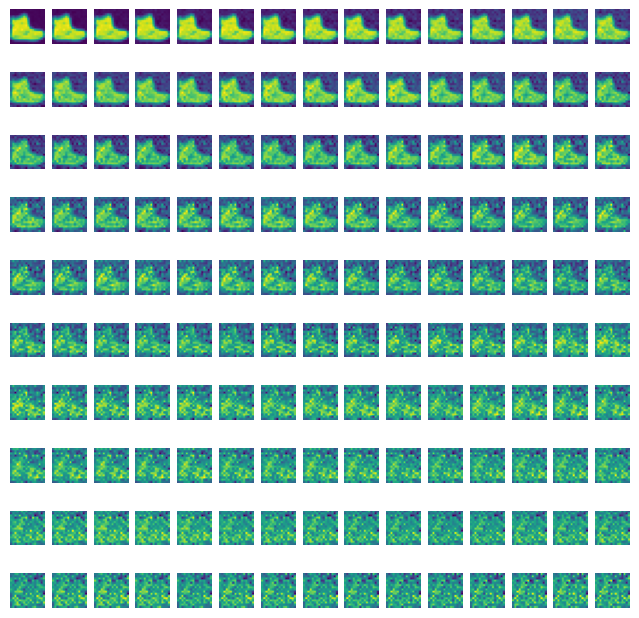

In [4]:
plt.figure(figsize=(8, 8))
x_0 = data[0][0].to(device)  # Initial image
x_t = x_0  # Set up recursion
xs = []  # Store x_t for each T to see change

for t in range(T):
    noise = torch.randn_like(x_t)
    x_t = torch.sqrt(1 - B[t]) * x_t + torch.sqrt(B[t]) * noise  # sample from q(x_t|x_t-1)
    img = torch.squeeze(x_t).cpu()
    xs.append(img)
    ax = plt.subplot(nrows, ncols, t + 1)
    ax.axis("off")
    plt.imshow(img)
plt.savefig("forward_diffusion.png", bbox_inches="tight")

O en forma animada:

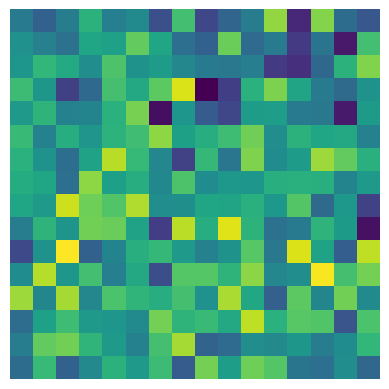

In [5]:
gif_name = "forward_diffusion.gif"
other_utils.save_animation(xs, gif_name)

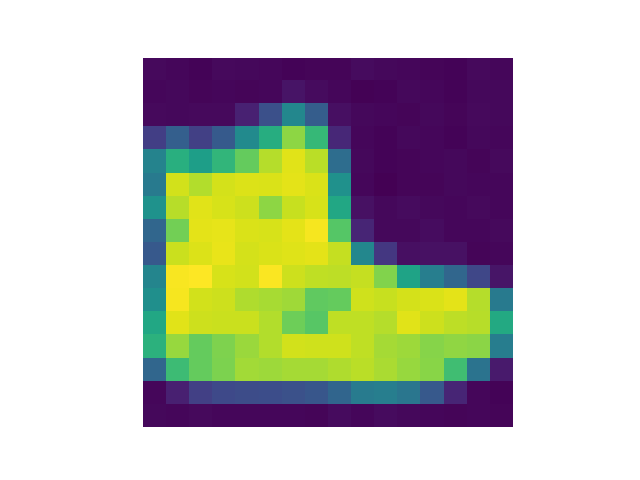

In [6]:
Image(open(gif_name,'rb').read())

## 2.2 Saltar adelante

Podríamos tomar cada imagen de nuestro conjunto de datos y añadirles ruido `T` veces para crear `T` imágenes nuevas más, pero ¿es necesario?

Gracias al poder de la recursividad, podemos estimar qué aspecto tendría $x_t$ dado nuestro programa beta $\beta_t$. En [Lilian Weng's Blog] (https://lilianweng.github.io/posts/2021-07-11-diffusion-models/#speed-up-diffusion-model-sampling) se puede encontrar un desglose completo de las matemáticas.
Volvamos a $\alpha$, que es el complemento de $\beta$. Podemos definir $\alpha_t$ como $1 - \beta_t$, y podemos definir $\bar{\alpha}_t$ como el [producto acumulativo](https://pytorch.org/docs/stable/generated/torch.cumprod.html) de $\alpha_t$.

Por ejemplo, $\bar{{alpha}_3 = \alpha_0 \cdot \alpha_1 \cdot \alpha_2 \cdot \alpha_3$.

Debido al símbolo de la barra, vamos a llamar $\bar{\alpha}_t$ `a_bar`. Nuestra nueva distribución de imagen ruidosa se convierte en:

$q(\mathbf{x}_{t}|\mathbf{x}_{0})=\mathcal{N}(\mathbf{x}_{t};\sqrt{\bar{\alpha}_{t}} x_{0},(1 - \bar{\alpha}_t) \cdot \mathbf{I})$

Que se traduce en código como:

`x_t = sqrt_a_bar_t * x_0 + sqrt_one_minus_a_bar_t * ruido`

Ahora ya no dependemos de $\mathbf{x}_{t-1}$ y podemos estimar $\mathbf{x}_t$ a partir de $x_0$. Vamos a definir estas variables en el código:

In [7]:
a = 1. - B
a_bar = torch.cumprod(a, dim=0)
sqrt_a_bar = torch.sqrt(a_bar)  # Mean Coefficient
sqrt_one_minus_a_bar = torch.sqrt(1 - a_bar) # St. Dev. Coefficient

Tenemos todas las piezas, vamos a codificar nuestra función de muestreo de difusión hacia adelante `q`:

$q(\mathbf{x}_{t}|\mathbf{x}_{0})=\mathcal{N}(\mathbf{x}_{t};\sqrt{\bar{\alpha}_{t}} \cdot \mathbf{x}_{0},(1 - \bar{\alpha}_t) \cdot \mathbf{I})$

Actualmente, `sqrt_a_bar` y `sqrt_one_minus_a_bar` sólo tienen una dimensión, y si indexamos en ellos con `t`, cada uno sólo tendrá un valor. Si queremos multiplicar este valor con cada uno de los valores de píxel de nuestras imágenes, tendremos que igualar el número de dimensiones para poder [emitir](https://numpy.org/doc/stable/user/basics.broadcasting.html).

Podemos añadir una dimensión extra indexando con `None`. Este es un atajo de PyTorch para añadir una dimensión extra al tensor resultante. Como referencia, un lote de imágenes tiene las dimensiones `dimensión del lote x canales de la imagen x altura de la imagen x anchura de la imagen`.

In [8]:
def q(x_0, t):
    """
    Samples a new image from q
    Returns the noise applied to an image at timestep t
    x_0: the original image
    t: timestep
    """
    t = t.int()
    noise = torch.randn_like(x_0)
    sqrt_a_bar_t = sqrt_a_bar[t, None, None, None]
    sqrt_one_minus_a_bar_t = sqrt_one_minus_a_bar[t, None, None, None]

    x_t = sqrt_a_bar_t * x_0 + sqrt_one_minus_a_bar_t * noise
    return x_t, noise

Vamos a probar este nuevo método en comparación con nuestro antiguo método de generación recursiva de las imágenes.

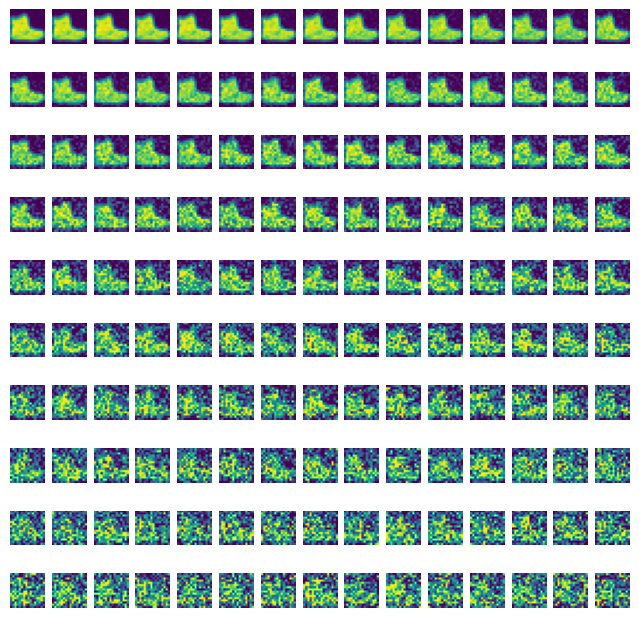

In [9]:
plt.figure(figsize=(8, 8))
xs = []

for t in range(T):
    t_tenser = torch.Tensor([t]).type(torch.int64)
    x_t, _ = q(x_0, t_tenser)
    img = torch.squeeze(x_t).cpu()
    xs.append(img)
    ax = plt.subplot(nrows, ncols, t + 1)
    ax.axis('off')
    other_utils.show_tensor_image(x_t)
plt.savefig("forward_diffusion_skip.png", bbox_inches='tight')

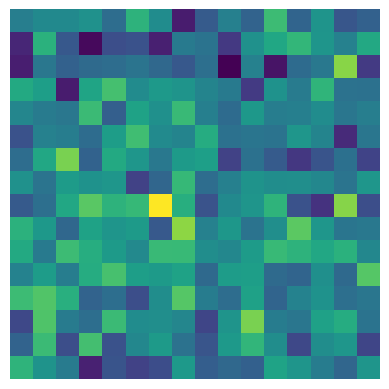

In [10]:
gif_name = "forward_diffusion_skip.gif"
other_utils.save_animation(xs, gif_name)

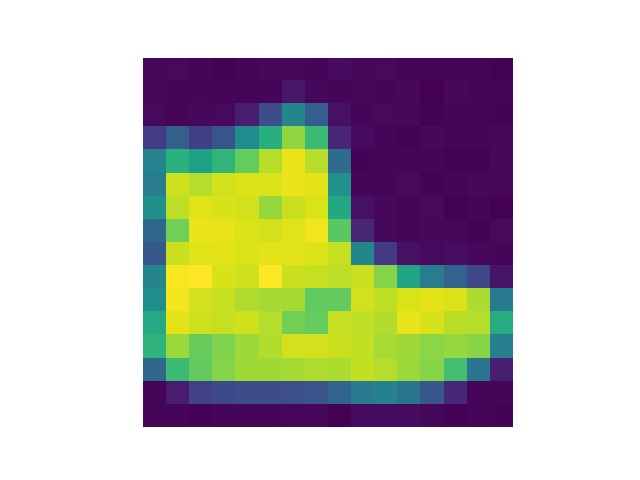

In [11]:
Image(open(gif_name,'rb').read())



---


# Pregunta 2

En comparación con la técnica anterior, ¿Se aprecia alguna diferencia visible en las imágenes cuando calculamos $q(x_t|x_0)$ respecto a cuando estimamos $q(x_t|x_{t-1})$? Asegúrese de hacer el zoom suficiente para notar la diferencia entre cada paso.


---



La diferencia que se visualiza en las imagenes de q(xt|xt−1) es que tienen un cambio suave ya que  el ruido se añade a la imagen en cada paso de tiempo, poco a poco, es decir de forma secuencial, ya que los datos se transforman de capa en capa. En cambio, cuando calculamos  q(xt|x0)  en las imagenes se observa que el patron es brusco, que las imagenes varian abruptamente, ya que se utilizan conexiones para saltar adelante, es mas directa, rapida y menos modificada entre capas, lo que puede brindar en la salida imagenes mas bruscas y se pierden los detalles más rapido.

## 2.3 Predicción del ruido

La arquitectura de nuestra red neuronal será prácticamente la misma que antes. Sin embargo, como la cantidad de ruido añadido cambia con cada paso de tiempo, necesitaremos una forma de decirle al modelo en qué paso de tiempo se encuentra nuestra imagen de entrada.

Para ello, podemos crear un bloque de incrustación como el siguiente.
* `input_dim` es el número de dimensiones del valor que queremos incrustar. Vamos a incrustar "t", que es un escalar unidimensional.
* `emb_dim` es el número de dimensiones en las que queremos convertir nuestro valor de entrada utilizando una capa [Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html).
* [UnFlatten](https://pytorch.org/docs/stable/generated/torch.nn.Unflatten.html) se utiliza para remodelar un vector en un espacio multidimensional. Dado que vamos a añadir el resultado de esta incrustación a un mapa de características multidimensional, añadiremos algunas dimensiones extra de forma similar a como expandimos la dimensión en la función `q` anterior.

In [22]:
class EmbedBlock(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super().__init__()
        self.input_dim = input_dim
        layers = [
            nn.Linear(input_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.Unflatten(1, (emb_dim, 1, 1))
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, input):
        input = input.view(-1, self.input_dim)
        return self.model(input)

Añadiremos este bloque de incrustación de tiempo a cada `UpBlock` de nuestra U-Net, dando como resultado la siguiente arquitectura.

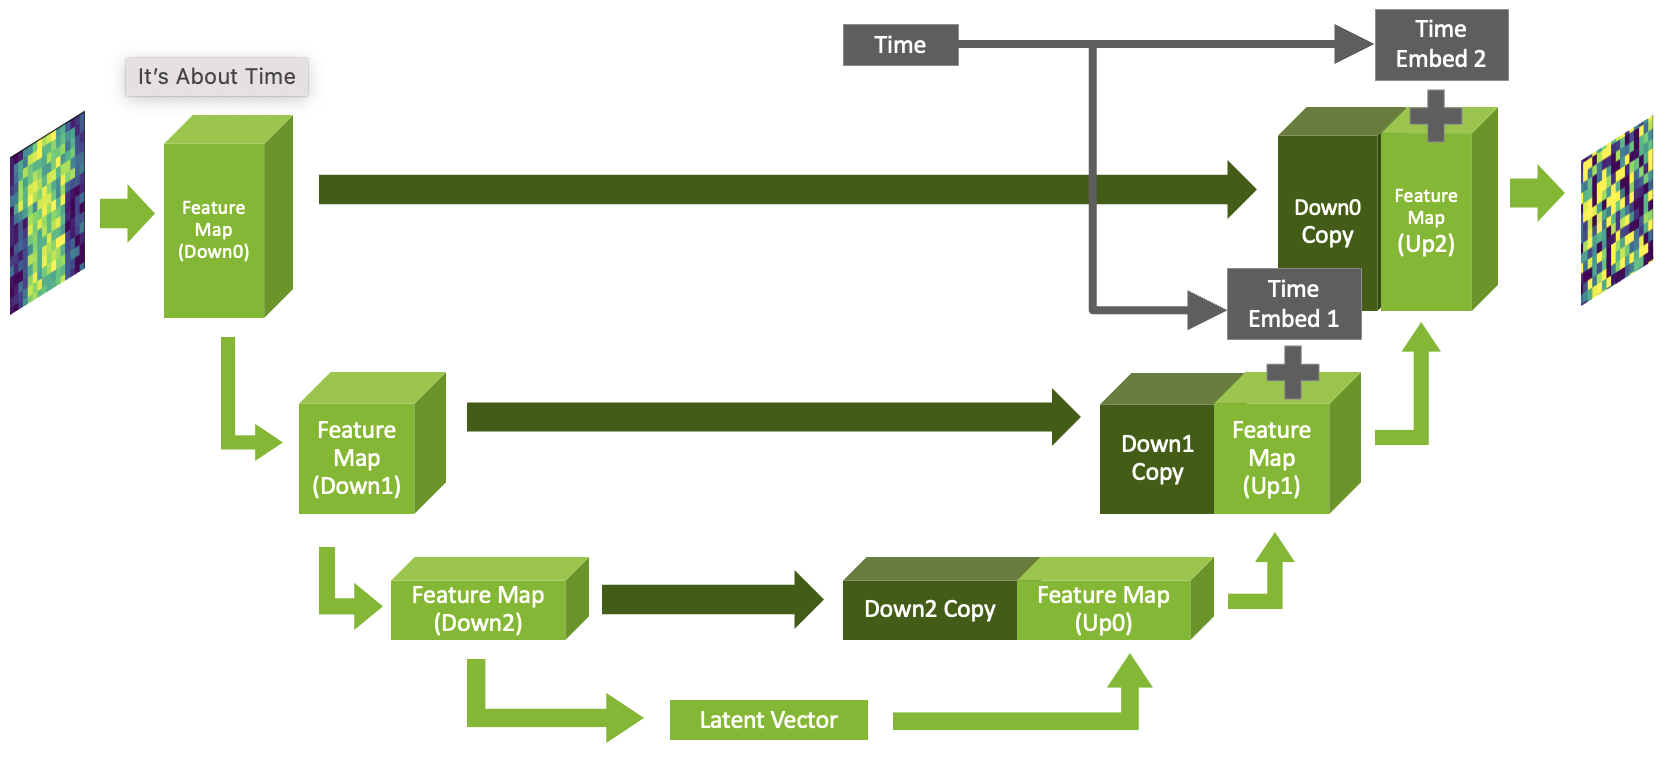

# Ejercicio 3

**TODO**: Nuestro `DownBlock` es el mismo que antes. Usando el laboratorioanterior como referencia, ¿puedes reemplazar los `FIXME`s con la variable correcta? Cada `FIXME` puede ser una de:
* `in_chs`
* `out_chs`
* `kernel_size`
* `stride`
* `padding`

In [23]:
class DownBlock(nn.Module):
    def __init__(self, in_chs, out_chs):
        kernel_size = 3
        stride = 1
        padding = 1

        super().__init__()
        layers = [
            nn.Conv2d(in_chs, out_chs, kernel_size, stride, padding),
            nn.BatchNorm2d(out_chs),
            nn.ReLU(),
            nn.Conv2d(out_chs, out_chs, kernel_size, stride, padding),
            nn.BatchNorm2d(out_chs),
            nn.ReLU(),
            nn.MaxPool2d(2)
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Ejercicio 4

**TODO**: ¿Puedes reemplazar los `FIXME`s con la variable correcta? Cada `FIXME` puede ser una de:
* `in_chs`
* `out_chs`
* `kernel_size`
* `stride`
* `padding`
* `strideT` *
* `out_paddingT` *
* `x`
* `skip`


In [24]:
class UpBlock(nn.Module):
    def __init__(self, in_chs, out_chs):
        # Convolution variables
        kernel_size = 3
        stride = 1
        padding = 1

        # Transpose variables
        strideT = 2
        out_paddingT = 1

        super().__init__()
        # 2 * in_chs for concatenated skip connection
        layers = [
            nn.ConvTranspose2d(2 * in_chs, out_chs, kernel_size, strideT, padding, out_paddingT),
            nn.BatchNorm2d(out_chs),
            nn.ReLU(),
            nn.Conv2d(out_chs, out_chs, kernel_size, stride, padding),
            nn.BatchNorm2d(out_chs),
            nn.ReLU()
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = torch.cat((x, skip), 1)
        x = self.model(x)
        return x

La U-Net final es similar a la que utilizamos en el primer laboratorio. La diferencia es que ahora tenemos una incrustación de tiempo conectada a nuestro `UpBlock`s.

In [25]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        img_chs = IMG_CH
        down_chs = (16, 32, 64)
        up_chs = down_chs[::-1]  # Reverse of the down channels
        latent_image_size = IMG_SIZE // 4 # 2 ** (len(down_chs) - 1)
        t_dim = 1 # New

        # Inital convolution
        self.down0 = nn.Sequential(
            nn.Conv2d(img_chs, down_chs[0], 3, padding=1),
            nn.BatchNorm2d(down_chs[0]),
            nn.ReLU()
        )

        # Downsample
        self.down1 = DownBlock(down_chs[0], down_chs[1])
        self.down2 = DownBlock(down_chs[1], down_chs[2])
        self.to_vec = nn.Sequential(nn.Flatten(), nn.ReLU())

        # Embeddings
        self.dense_emb = nn.Sequential(
            nn.Linear(down_chs[2]*latent_image_size**2, down_chs[1]),
            nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[1]),
            nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[2]*latent_image_size**2),
            nn.ReLU()
        )
        self.temb_1 = EmbedBlock(t_dim, up_chs[0])  # New
        self.temb_2 = EmbedBlock(t_dim, up_chs[1])  # New

        # Upsample
        self.up0 = nn.Sequential(
            nn.Unflatten(1, (up_chs[0], latent_image_size, latent_image_size)),
            nn.Conv2d(up_chs[0], up_chs[0], 3, padding=1),
            nn.BatchNorm2d(up_chs[0]),
            nn.ReLU(),
        )
        self.up1 = UpBlock(up_chs[0], up_chs[1])
        self.up2 = UpBlock(up_chs[1], up_chs[2])

        # Match output channels
        self.out = nn.Sequential(
            nn.Conv2d(up_chs[-1], up_chs[-1], 3, 1, 1),
            nn.BatchNorm2d(up_chs[-1]),
            nn.ReLU(),
            nn.Conv2d(up_chs[-1], img_chs, 3, 1, 1)
        )

    def forward(self, x, t):
        down0 = self.down0(x)
        down1 = self.down1(down0)
        down2 = self.down2(down1)
        latent_vec = self.to_vec(down2)

        # New
        t = t.float() / T  # Convert from [0, T] to [0, 1]
        latent_vec = self.dense_emb(latent_vec)
        temb_1 = self.temb_1(t)
        temb_2 = self.temb_2(t)

        up0 = self.up0(latent_vec)
        up1 = self.up1(up0+temb_1, down2)
        up2 = self.up2(up1+temb_2, down1)
        return self.out(up2)

In [26]:
model = UNet()
print("Num params: ", sum(p.numel() for p in model.parameters()))
model = torch.compile(UNet().to(device))

Num params:  240385


### 2.3.1 La función de pérdida

En el primer labraotorio (LAB 8), utilizamos una función de pérdida [Error cuadrático medio](https://developers.google.com/machine-learning/glossary#mean-squared-error-mse) comparando la imagen original y la imagen original predicha en función del ruido.

Esta vez, compararemos el ruido real que se añadió a la imagen y el ruido predicho. Lilian Weng profundiza en las matemáticas en esta [entrada de blog](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/#parameterization-of-l_t-for-training-loss). Originalmente, la función de pérdida se basaba en el [Evidence Lower Bound (ELBO)](https://en.wikipedia.org/wiki/Evidence_lower_bound) [Log-Likelihood](https://mathworld.wolfram.com/Log-LikelihoodFunction.html), pero se descubrió en el [Denoising Diffusion Probabilistic Models Paper](https://arxiv.org/abs/2006.11239) que el Error Cuadrático Medio entre el ruido predicho y el ruido real era mejor en la práctica. Si tienes curiosidad, Lilian Weng explica la derivación [aquí](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/#reverse-diffusion-process).

In [27]:
def get_loss(model, x_0, t):
    x_noisy, noise = q(x_0, t)
    noise_pred = model(x_noisy, t)
    return F.mse_loss(noise, noise_pred)

## 2.4 Difusión inversa

Ahora tenemos un modelo que predice el ruido añadido a una imagen en el paso de tiempo `t`, pero generar imágenes no es tan fácil como restar y añadir ruido repetidamente. La función `q` puede invertirse de forma que generemos $\mathbf{x}_{t-1}$ a partir de $\mathbf{x}_t$.

$q(\mathbf{x}_{t-1}|\mathbf{x}_{t},\mathbf{x}_{0}) = \mathcal{N}(\mathbf{x}_{t-1};{\mathbf{\tilde{\mu}}}(\mathbf{x_t},\mathbf{x_0}), \tilde{\beta}_t \cdot \mathbf{I})$

**Nota**: $\tilde{\beta}_t$ se calculó originalmente para ser $\frac{1-\overline{a}_{t-1}}{1-\overline{a}_{t}}\beta_t$, pero en la práctica, utilizar sólo $\beta_t$ es más eficaz

Usando el [Teorema de Bayes](https://en.wikipedia.org/wiki/Bayes%27_theorem), podemos derivar una ecuación para la media del modelo `u_t` en el paso de tiempo `t`.

${\mathbf{\tilde{\mu}}}_t = \frac{1}{\sqrt{\alpha_t}}(\mathbf{x_t}-\frac{1-\alpha_t}{\sqrt{1-\overline{\alpha_t}}}\mathbf{\epsilon}_t)$

La imagen $\mathbf{x}_{t-1}$ puede estimarse mediante ${\mathbf{\tilde{\mu}}}_t + \tilde{\beta}_t \cdot \mathbf{I}$, así que usaremos esta ecuación para generar imágenes de muestra recursivamente hasta llegar a `t == 0`. Veamos qué significa esto en código. En primer lugar, vamos a precalcular los valores necesarios para calcular `u_t`.

In [28]:
sqrt_a_inv = torch.sqrt(1 / a)
pred_noise_coeff = (1 - a) / torch.sqrt(1 - a_bar)

A continuación, crearemos la función de difusión inversa, `reverse_q`.

In [29]:
@torch.no_grad()
def reverse_q(x_t, t, e_t):
    t = torch.squeeze(t[0].int())  # All t values should be the same
    pred_noise_coeff_t = pred_noise_coeff[t]
    sqrt_a_inv_t = sqrt_a_inv[t]
    u_t = sqrt_a_inv_t * (x_t - pred_noise_coeff_t * e_t)
    if t == 0:
        return u_t  # Reverse diffusion complete!
    else:
        B_t = B[t-1]
        new_noise = torch.randn_like(x_t)
        return u_t + torch.sqrt(B_t) * new_noise

Vamos a crear una función para eliminar iterativamente el ruido de una imagen hasta que esté libre de ruido. También vamos a mostrar estas imágenes para que podamos ver cómo mejora el modelo.

In [30]:
@torch.no_grad()
def sample_images(ncols, figsize=(8,8)):
    plt.figure(figsize=figsize)
    plt.axis("off")
    hidden_rows = T / ncols

    # Noise to generate images from
    x_t = torch.randn((1, IMG_CH, IMG_SIZE, IMG_SIZE), device=device)

    # Go from T to 0 removing and adding noise until t = 0
    plot_number = 1
    for i in range(0, T)[::-1]:
        t = torch.full((1,), i, device=device)
        e_t = model(x_t, t)  # Predicted noise
        x_t = reverse_q(x_t, t, e_t)
        if i % hidden_rows == 0:
            ax = plt.subplot(1, ncols+1, plot_number)
            ax.axis('off')
            other_utils.show_tensor_image(x_t.detach().cpu())
            plot_number += 1
    plt.show()

¡Es hora de entrenar el modelo! ¿Qué te parece? ¿Parece que el modelo está aprendiendo?

/usr/local/lib/python3.10/dist-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0 | Step 000 | Loss: 1.2749364376068115 


<ipython-input-30-3663ad27705e>:17: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(1, ncols+1, plot_number)


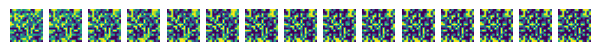

Epoch 0 | Step 100 | Loss: 0.4415040612220764 


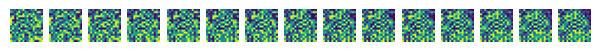

Epoch 0 | Step 200 | Loss: 0.31109267473220825 


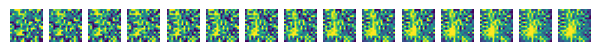

Epoch 0 | Step 300 | Loss: 0.269270122051239 


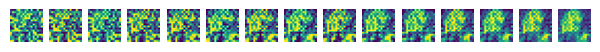

Epoch 0 | Step 400 | Loss: 0.22452816367149353 


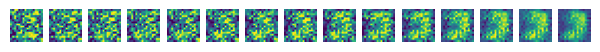

Epoch 0 | Step 500 | Loss: 0.23634716868400574 


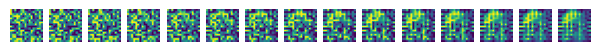

Epoch 1 | Step 000 | Loss: 0.2431836724281311 


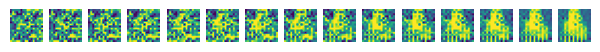

Epoch 1 | Step 100 | Loss: 0.21352577209472656 


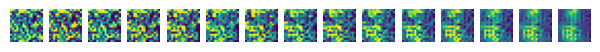

Epoch 1 | Step 200 | Loss: 0.23386073112487793 


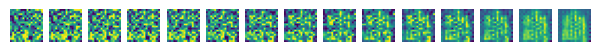

Epoch 1 | Step 300 | Loss: 0.21253705024719238 


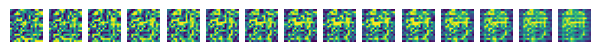

Epoch 1 | Step 400 | Loss: 0.18737059831619263 


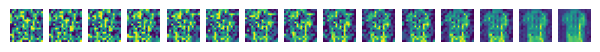

Epoch 1 | Step 500 | Loss: 0.19956061244010925 


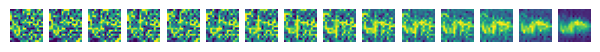

Epoch 2 | Step 000 | Loss: 0.1800689697265625 


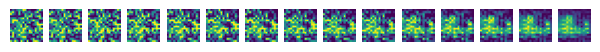

Epoch 2 | Step 100 | Loss: 0.15124455094337463 


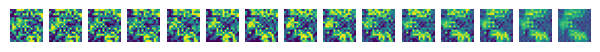

Epoch 2 | Step 200 | Loss: 0.19402000308036804 


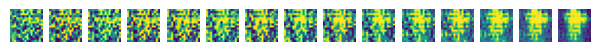

Epoch 2 | Step 300 | Loss: 0.1710447371006012 


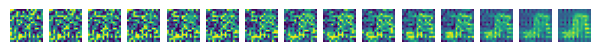

Epoch 2 | Step 400 | Loss: 0.1657569408416748 


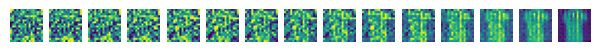

Epoch 2 | Step 500 | Loss: 0.16605322062969208 


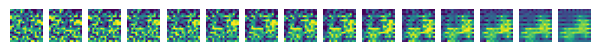

Final sample:


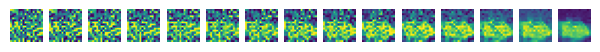

In [31]:
optimizer = Adam(model.parameters(), lr=0.001)
epochs = 3
ncols = 15  # Should evenly divide T

model.train()
for epoch in range(epochs):
    for step, batch in enumerate(dataloader):
        optimizer.zero_grad()

        t = torch.randint(0, T, (BATCH_SIZE,), device=device)
        x = batch[0].to(device)
        loss = get_loss(model, x, t)
        loss.backward()
        optimizer.step()

        if epoch % 1 == 0 and step % 100 == 0:
            print(f"Epoch {epoch} | Step {step:03d} | Loss: {loss.item()} ")
            sample_images(ncols)
print("Final sample:")
sample_images(ncols)

Si entrecierras los ojos, ¿puedes distinguir lo que genera el modelo?

<ipython-input-30-3663ad27705e>:17: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(1, ncols+1, plot_number)


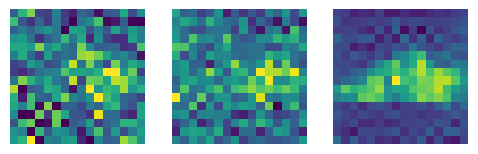

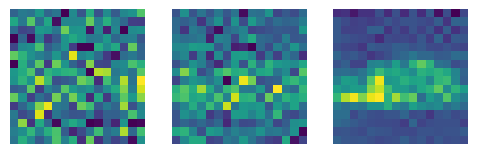

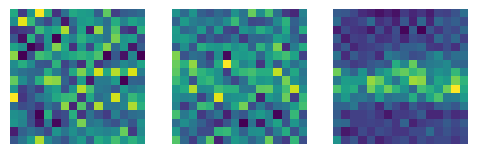

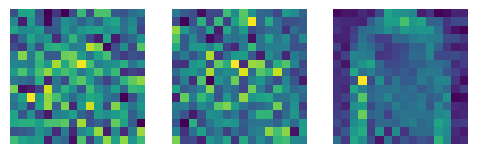

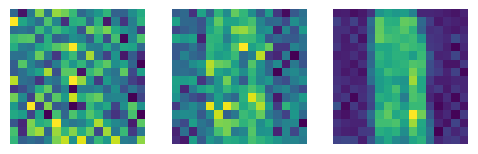

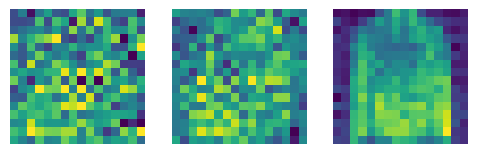

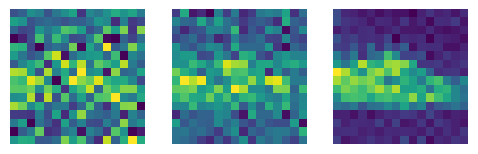

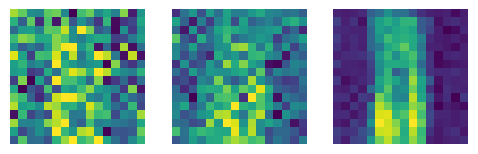

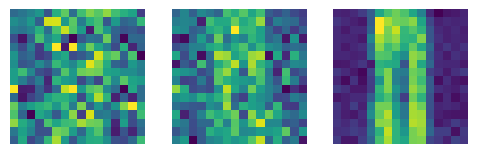

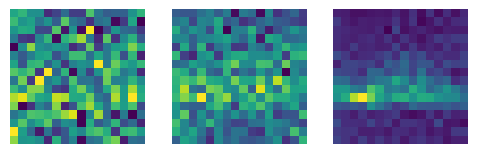

In [32]:
model.eval()
figsize=(8,8) # Change me
ncols = 3 # Should evenly divide T
for _ in range(10):
    sample_images(ncols, figsize=figsize)